# Intern Performance Prediction Model


In [1]:
!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## Load Dataset


In [2]:
import os

file_path = 'intern_performance.csv'

if os.path.exists(file_path):
    data = pd.read_csv(file_path)
else:
    # Self-contained fallback dataset generation
    np.random.seed(42)
    n = 1000
    tasks_assigned = np.random.randint(10, 41, n)
    completion_rate = np.clip(np.random.normal(82, 14, n), 35, 100)
    tasks_completed = np.maximum(1, np.rint(tasks_assigned * completion_rate / 100).astype(int))
    tasks_completed = np.minimum(tasks_completed, tasks_assigned)
    avg_completion_time = np.clip(np.random.normal(3.4, 1.1, n) - (completion_rate - 75) * 0.012, 1, 7)
    feedback_rating = np.clip(np.random.normal(3.7, 0.75, n) + (completion_rate - 80) * 0.008, 1, 5)
    attendance_percentage = np.clip(np.random.normal(88, 8, n) + (completion_rate - 80) * 0.08, 55, 100)
    late_submissions = np.clip(np.rint(np.random.poisson(2.2, n) + (75 - completion_rate) / 18).astype(int), 0, 10)
    teamwork_rating = np.clip(np.random.normal(3.7, 0.7, n) + (feedback_rating - 3.5) * 0.25, 1, 5)
    communication_rating = np.clip(np.random.normal(3.6, 0.75, n) + (feedback_rating - 3.5) * 0.25, 1, 5)
    technical_skill_rating = np.clip(np.random.normal(3.6, 0.8, n) + (completion_rate - 80) * 0.012, 1, 5)
    skill_score = (teamwork_rating + communication_rating + technical_skill_rating) / 3
    performance_score = (0.34 * completion_rate + 0.17 * attendance_percentage + 7 * feedback_rating + 3 * teamwork_rating + 3 * communication_rating + 4 * technical_skill_rating - 2.2 * avg_completion_time - 1.7 * late_submissions + np.random.normal(0, 4.5, n))
    performance_score = np.clip(performance_score * 0.55 - 15, 0, 100)
    data = pd.DataFrame({
        'intern_id': [f'INT{str(i).zfill(4)}' for i in range(1, n + 1)],
        'tasks_assigned': tasks_assigned,
        'tasks_completed': tasks_completed,
        'avg_completion_time': np.round(avg_completion_time, 2),
        'feedback_rating': np.round(feedback_rating, 2),
        'attendance_percentage': np.round(attendance_percentage, 2),
        'late_submissions': late_submissions,
        'teamwork_rating': np.round(teamwork_rating, 2),
        'communication_rating': np.round(communication_rating, 2),
        'technical_skill_rating': np.round(technical_skill_rating, 2),
        'performance_score': np.round(performance_score, 2)
    })

print('Dataset shape:', data.shape)
data.head()

Dataset shape: (1000, 11)


,intern_id,tasks_assigned,tasks_completed,avg_completion_time,feedback_rating,attendance_percentage,late_submissions,teamwork_rating,communication_rating,technical_skill_rating,performance_score
0,INT0001,16,14,2.18,2.57,90.04,2,1.93,2.97,4.24,34.02
1,INT0002,29,23,1.87,4.40,91.84,3,3.31,5.00,4.93,46.00
2,INT0003,38,33,4.02,4.24,99.50,0,3.85,4.73,4.12,41.86
3,INT0004,24,21,4.54,2.59,87.81,0,3.62,3.89,2.16,34.82
4,INT0005,20,10,3.23,3.28,80.69,6,4.83,3.88,3.19,24.08


## Data Understanding

In [3]:
data.shape

(1000, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   intern_id               1000 non-null   object 
 1   tasks_assigned          1000 non-null   int32  
 2   tasks_completed         1000 non-null   int64  
 3   avg_completion_time     1000 non-null   float64
 4   feedback_rating         1000 non-null   float64
 5   attendance_percentage   1000 non-null   float64
 6   late_submissions        1000 non-null   int64  
 7   teamwork_rating         1000 non-null   float64
 8   communication_rating    1000 non-null   float64
 9   technical_skill_rating  1000 non-null   float64
 10  performance_score       1000 non-null   float64
dtypes: float64(7), int32(1), int64(2), object(1)
memory usage: 82.2+ KB


In [5]:
data.describe().round(2)

,tasks_assigned,tasks_completed,avg_completion_time,feedback_rating,attendance_percentage,late_submissions,teamwork_rating,communication_rating,technical_skill_rating,performance_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,25.45,20.57,3.32,3.70,87.72,1.88,3.73,3.66,3.58,36.80
std,9.24,8.19,1.08,0.72,7.52,1.48,0.72,0.77,0.76,6.43
min,10.00,5.00,1.00,1.27,63.69,0.00,1.46,1.17,1.00,14.48
25%,17.00,14.00,2.56,3.21,82.88,1.00,3.22,3.12,3.09,32.42
50%,26.00,21.00,3.30,3.70,87.72,2.00,3.73,3.68,3.58,37.03
75%,34.00,27.00,4.05,4.20,93.35,3.00,4.25,4.18,4.11,41.10
max,40.00,40.00,6.38,5.00,100.00,9.00,5.00,5.00,5.00,56.66


In [6]:
data.isnull().sum()

intern_id                 0
tasks_assigned            0
tasks_completed           0
avg_completion_time       0
feedback_rating           0
attendance_percentage     0
late_submissions          0
teamwork_rating           0
communication_rating      0
technical_skill_rating    0
performance_score         0
dtype: int64

In [7]:
print('Duplicate rows:', data.duplicated().sum())

Duplicate rows: 0


## Data Cleaning


In [8]:
# Remove duplicate records
data = data.drop_duplicates().copy()

# Check for missing values
print(data.isnull().sum())

# Validate logical relationships
data['tasks_completed'] = data[['tasks_completed', 'tasks_assigned']].min(axis=1)
print('\nCleaned shape:', data.shape)

intern_id                 0
tasks_assigned            0
tasks_completed           0
avg_completion_time       0
feedback_rating           0
attendance_percentage     0
late_submissions          0
teamwork_rating           0
communication_rating      0
technical_skill_rating    0
performance_score         0
dtype: int64

Cleaned shape: (1000, 11)


## Feature Engineering


In [9]:
data['completion_rate'] = (data['tasks_completed'] / data['tasks_assigned']) * 100
data['skill_score'] = (
    data['teamwork_rating'] +
    data['communication_rating'] +
    data['technical_skill_rating']
) / 3

data['completion_rate'] = data['completion_rate'].round(2)
data['skill_score'] = data['skill_score'].round(2)

data[['tasks_assigned', 'tasks_completed', 'completion_rate', 'skill_score']].head()

,tasks_assigned,tasks_completed,completion_rate,skill_score
0,16,14,87.50,3.05
1,29,23,79.31,4.41
2,38,33,86.84,4.23
3,24,21,87.50,3.22
4,20,10,50.00,3.97


## Exploratory Data Analysis (EDA)

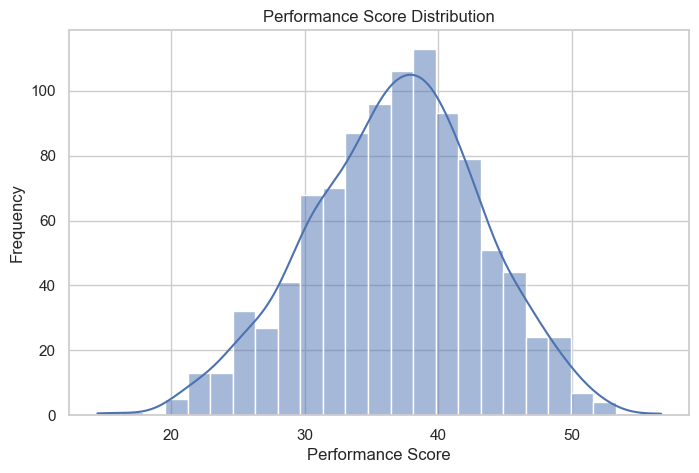

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data['performance_score'], kde=True)
plt.title('Performance Score Distribution')
plt.xlabel('Performance Score')
plt.ylabel('Frequency')
plt.show()


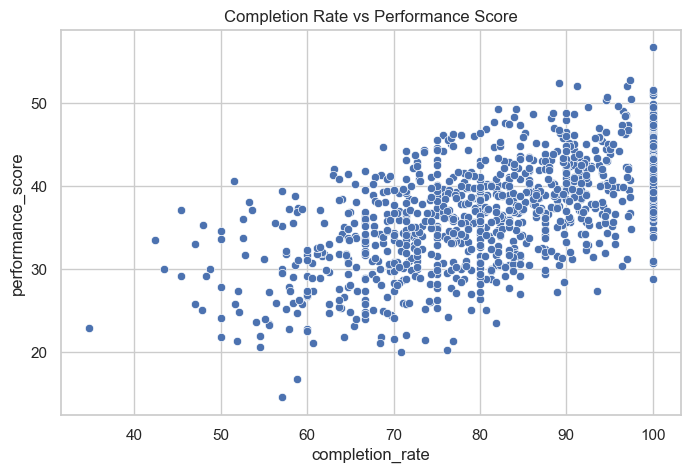

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='completion_rate', y='performance_score')
plt.title('Completion Rate vs Performance Score')
plt.show()


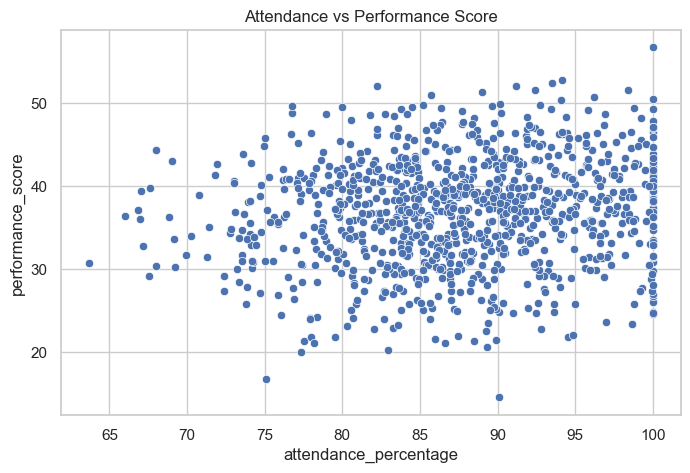

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='attendance_percentage', y='performance_score')
plt.title('Attendance vs Performance Score')
plt.show()


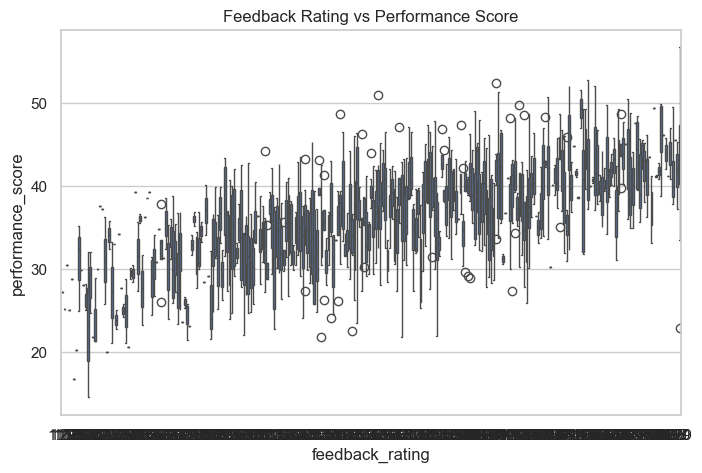

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data, x='feedback_rating', y='performance_score')
plt.title('Feedback Rating vs Performance Score')
plt.show()


## Correlation Analysis

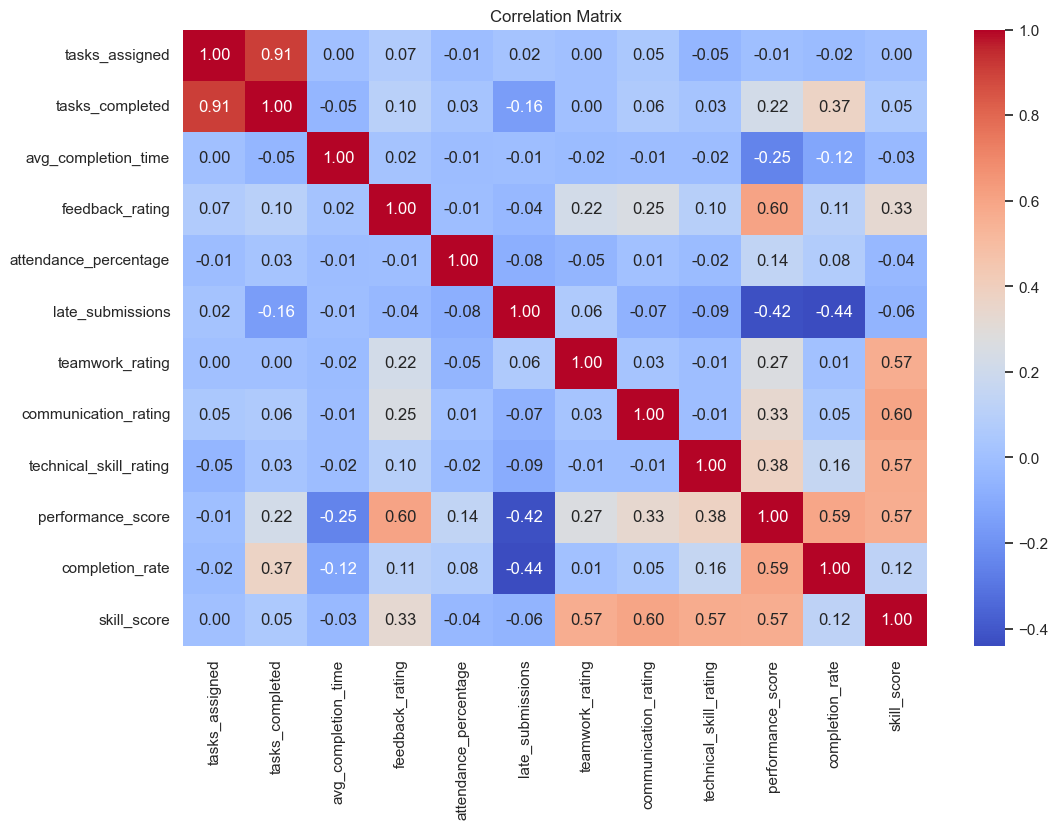

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Prepare Features and Target


In [15]:
X = data.drop(['intern_id', 'performance_score'], axis=1)
y = data['performance_score']

print('Features:', list(X.columns))
print('Target:', y.name)

Features: ['tasks_assigned', 'tasks_completed', 'avg_completion_time', 'feedback_rating', 'attendance_percentage', 'late_submissions', 'teamwork_rating', 'communication_rating', 'technical_skill_rating', 'completion_rate', 'skill_score']
Target: performance_score


## Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 800
Testing samples: 200


## Random Forest Regression

In [17]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [18]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f'Random Forest MAE: {rf_mae:.3f}')
print(f'Random Forest RMSE: {rf_rmse:.3f}')
print(f'Random Forest R²: {rf_r2:.3f}')

Random Forest MAE: 2.437
Random Forest RMSE: 2.997
Random Forest R²: 0.780


## XGBoost Regression

In [19]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

In [20]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f'XGBoost MAE: {xgb_mae:.3f}')
print(f'XGBoost RMSE: {xgb_rmse:.3f}')
print(f'XGBoost R²: {xgb_r2:.3f}')

XGBoost MAE: 2.262
XGBoost RMSE: 2.747
XGBoost R²: 0.815


## Model Comparison

In [21]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'MAE': [rf_mae, xgb_mae],
    'RMSE': [rf_rmse, xgb_rmse],
    'R2 Score': [rf_r2, xgb_r2]
}).sort_values('R2 Score', ascending=False)

results.round(3)

,Model,MAE,RMSE,R2 Score
1,XGBoost,2.262,2.747,0.815
0,Random Forest,2.437,2.997,0.780


In [22]:
best_model_name = results.iloc[0]['Model']
best_model = rf_model if best_model_name == 'Random Forest' else xgb_model
print('Best model based on R²:', best_model_name)

Best model based on R²: XGBoost



## Actual vs Predicted Performance

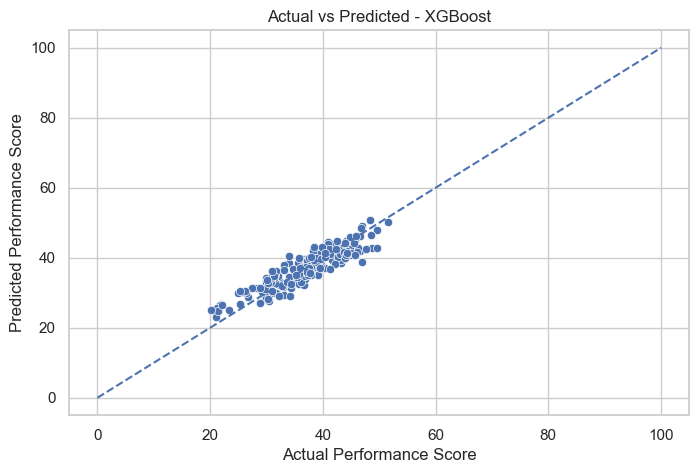

In [23]:
best_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=best_pred)
plt.xlabel('Actual Performance Score')
plt.ylabel('Predicted Performance Score')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.plot([0, 100], [0, 100], linestyle='--')
plt.show()

## Feature Importance

,Importance
completion_rate,0.285605
feedback_rating,0.276414
skill_score,0.183514
late_submissions,0.093831
avg_completion_time,0.047946
technical_skill_rating,0.038957
attendance_percentage,0.023424
communication_rating,0.019105
teamwork_rating,0.013730
tasks_completed,0.009386


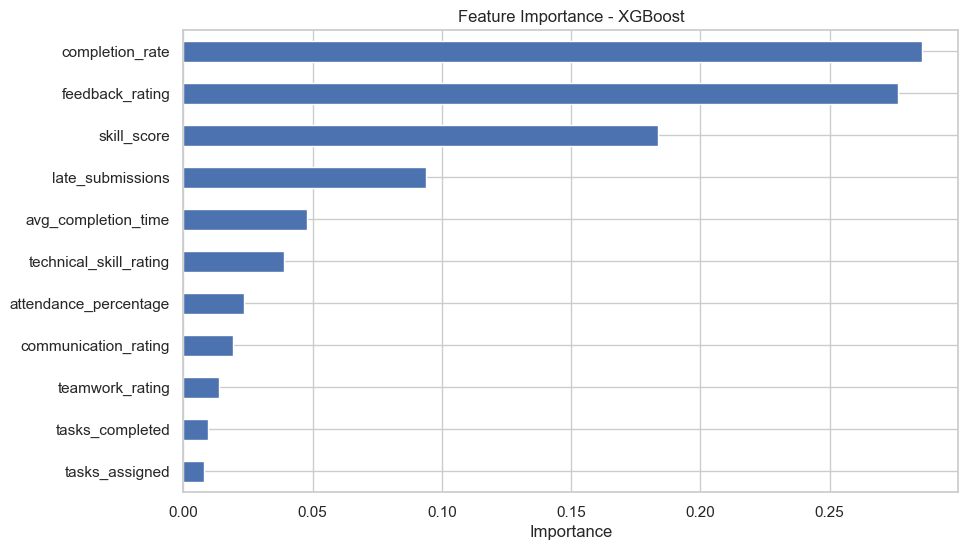

In [24]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importance.to_frame('Importance'))

plt.figure(figsize=(10, 6))
importance.sort_values().plot(kind='barh')
plt.title(f'Feature Importance - {best_model_name}')
plt.xlabel('Importance')
plt.show()

## Predict a New Intern


In [25]:
new_intern = pd.DataFrame({
    'tasks_assigned': [20],
    'tasks_completed': [18],
    'avg_completion_time': [2.5],
    'feedback_rating': [4.5],
    'attendance_percentage': [95],
    'late_submissions': [1],
    'teamwork_rating': [4.0],
    'communication_rating': [5.0],
    'technical_skill_rating': [4.0]
})

new_intern['completion_rate'] = (
    new_intern['tasks_completed'] / new_intern['tasks_assigned']
) * 100

new_intern['skill_score'] = (
    new_intern['teamwork_rating'] +
    new_intern['communication_rating'] +
    new_intern['technical_skill_rating']
) / 3

predicted_score = best_model.predict(new_intern[X.columns])[0]
predicted_score = float(np.clip(predicted_score, 0, 100))

print(f'Predicted Performance Score: {predicted_score:.2f}')

Predicted Performance Score: 48.12


## Performance Category


In [26]:
def performance_category(score):
    if score >= 80:
        return 'Excel'
    elif score >= 60:
        return 'Average'
    else:
        return 'Struggle'

category = performance_category(predicted_score)

print('Performance Category:', category)

Performance Category: Struggle
